In [25]:
import pandas as pd
import os
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.ticker import MultipleLocator
import networkx as nx
from scipy.stats import zscore
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import fdrcorrection
import math
from scipy.stats import pointbiserialr
from matplotlib.colors import LinearSegmentedColormap

In [26]:
plt.rcParams['svg.fonttype'] = 'none'

### Load data

In [27]:
gnpc_hc = pd.read_csv('./data/GNPC_HC_clinical.csv')

In [28]:
pl_meta_sex_idx = pd.read_csv("./results/gnpc_meta_sex_idx_update.csv")
cell_type_performance = pd.read_csv("./results/Rev_UPDATE_cell_type_performance_gnpc_update_0912.csv")
df_age_gap = pd.read_csv("./results/Rev_UPDATE_gnpc_cell_type_gaps_z_v3.3_by_COHORT_HC_across_cohorts_z.csv")

In [29]:
pl_meta_sex_idx['hc'] = pl_meta_sex_idx['sample_id'].isin(gnpc_hc['sample_id']).astype(int)

Remove low performing and sex-specific cell types

In [ ]:
drop_1=["Spermatogonia", "Late spermatids", 
          "Early spermatids",  "Spermatocytes", 
          "Oocytes", "Syncytiotrophoblasts", 
          "Extravillous trophoblasts", 
          "Cytotrophoblasts", 
          "Peritubular cells",
          "Sertoli cells",
          "Prostatic glandular cells"]

drop_2 = ["Breast myoepithelial cells",
"Ductal cells", "Ovarian stromal cells", "Leydig cells", "Basal squamous epithelial cells",
"Salivary duct cells", "Basal keratinocytes", "Collecting duct cells",
"Endometrial stromal cells", "Basal prostatic cells", "Granulosa cells", "Cytotrophoblasts",
"Secretory cells", "Rod photoreceptor cells", "Glandular and luminal cells",
"Squamous epithelial cells", "Cone photoreceptor cells", "Distal enterocytes",
"Club cells", "Paneth cells", "Ionocytes", "Cholangiocytes", "Melanocytes"]

low_performing_cells = cell_type_performance[cell_type_performance['evaluation_gnpc'] < 0.15]
low_performing_cell_types = low_performing_cells['cell_type'].tolist()
low_performing_cell_types = [cell_type.replace(" ", ".") for cell_type in low_performing_cells['cell_type'].tolist()]

import re
low_performing_cell_types = [re.sub(r"\.", " ", cell_type) for cell_type in low_performing_cell_types]
unique_low_performers = [cell_type for cell_type in low_performing_cell_types 
                        if cell_type not in drop_1 and cell_type not in drop_2]

age_gap_df = df_age_gap.iloc[:, 2:]
columns_to_drop = drop_1 + drop_2 + unique_low_performers 
filtered_age_gap_df = age_gap_df.drop(columns=columns_to_drop)
filtered_age_gap_df.head()

,Adipocytes,Alveolar cells type 1,Alveolar cells type 2,Astrocytes,B cells,Basal respiratory cells,Breast glandular cells,Cardiomyocytes,Ciliated cells,Distal tubular cells,...,Proximal tubular cells,Schwann cells,Serous glandular cells,Skeletal myocytes,Smooth muscle cells,Suprabasal keratinocytes,T cells,dendritic cells,granulocytes,monocytes
0,-0.159425,-1.710388,0.100332,-0.161194,1.166856,1.042000,0.125687,-0.355195,-1.207320,-1.478635,...,-0.434884,-0.319999,-0.620534,-0.154790,0.345272,-0.594454,-0.269353,1.755543,-0.334738,0.249148
1,0.759192,-0.073912,0.761840,0.514613,-0.668403,0.006805,-0.331339,0.017225,-1.752482,1.191837,...,-0.175468,-0.928225,-0.452130,0.088308,2.446099,-0.588049,0.091182,0.472148,0.434692,0.246752
2,1.833792,0.314897,1.597285,-0.799942,-0.277941,-0.056882,0.218156,-0.096676,-1.036977,-1.197992,...,-0.601175,-0.662575,0.499606,-0.651022,-0.218070,-0.101160,-0.874203,0.605767,-1.071982,-0.362439
3,1.133602,0.421317,0.534344,-0.584994,0.176620,-0.302407,-0.640486,0.686703,1.243809,-0.009441,...,0.314201,0.256206,0.229021,0.443916,1.009395,0.706337,-0.407602,-0.292575,0.848579,0.900432
4,0.255568,0.184588,-0.895706,-0.759750,-1.585075,-1.222185,-0.244571,-1.199156,-0.708216,-0.692224,...,-0.948752,-0.775857,0.168051,-0.713632,0.227038,-1.198503,-0.503307,-3.135970,-1.978870,-0.894968


### Cognition analysis

In [34]:
cdr_cohort = ['J', 'F', 'N', 'D', 'I', 'L', 'Q', 'P']

# Filter data to include only rows with valid CDR values (not -1 and not NaN)
cdr_df = pl_meta_sex_idx[(pl_meta_sex_idx['cdr'].notna()) & 
                         (pl_meta_sex_idx['cdr'] != -1) &
                         (pl_meta_sex_idx['contributor_code'].isin(cdr_cohort))].copy()

# Count the number of people in each cohort
cohort_counts = cdr_df['contributor_code'].value_counts().reindex(cdr_cohort).fillna(0).astype(int)
cohort_counts

contributor_code
J     414
F    2909
N     788
D     391
I     485
L    1085
Q    1317
P     517
Name: count, dtype: int64

In [35]:
cdr_categories = [0, 0.5, 1, 2, 3]

# Get counts for each CDR category
cdr_category_counts = cdr_df['cdr'].value_counts().reindex(cdr_categories).fillna(0).astype(int)

cdr_by_cohort = cdr_df.groupby(['contributor_code', 'cdr']).size().unstack(fill_value=0)

for cat in cdr_categories:
    if cat not in cdr_by_cohort.columns:
        cdr_by_cohort[cat] = 0

cdr_by_cohort = cdr_by_cohort[cdr_categories]

cdr_by_cohort = cdr_by_cohort.reindex(cdr_cohort, fill_value=0)

In [36]:
cdr_by_cohort

cdr,0.0,0.5,1.0,2.0,3.0
contributor_code,,,,,
J,245,126,29,10,4
F,1469,0,1276,154,10
N,402,153,140,70,23
D,198,100,66,13,14
I,222,180,49,22,12
L,612,290,71,63,49
Q,933,0,333,51,0
P,482,35,0,0,0


In [37]:
cdr_cohort = ['D', 'F', 'I', 'J', 'L', 'N', 'Q', 'P']

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests


cdr_cohort = ['D', 'F', 'I', 'J', 'L', 'N', 'Q', 'P']

pl_meta_sex_idx.index = pl_meta_sex_idx['sample_id']
df_age_gap.index = pl_meta_sex_idx['sample_id']
filtered_age_gap_df.index = pl_meta_sex_idx['sample_id']

cohort_mask = pl_meta_sex_idx['contributor_code'].isin(cdr_cohort)
cohort_meta = pl_meta_sex_idx[cohort_mask]

# Get the corresponding age gap data for the cohort
cohort_age_gap = filtered_age_gap_df.loc[cohort_meta.index]

# Perform correlation analysis for each cell type
correlation_results = []

for cell in cohort_age_gap.columns:
    # Create a temporary dataframe with the current cell type and CDR scores
    temp_df = pd.DataFrame({
        'age_gap': cohort_age_gap[cell],
        'cdr': cohort_meta['cdr']
    })
        
    temp_df = temp_df[(temp_df['cdr'] != -1) & (temp_df['cdr'].notna())]    
    temp_df = temp_df.dropna()
    
    # Calculate correlation if we have sufficient data
    if len(temp_df) > 5:  # Require at least 5 samples for meaningful correlation
        corr, p_val = pearsonr(temp_df['age_gap'], temp_df['cdr'])
        
        correlation_results.append({
            'cell_type': cell,
            'correlation': corr,
            'p_value': p_val
        })
    else:
        correlation_results.append({
            'cell_type': cell,
            'correlation': np.nan,
            'p_value': np.nan
        })

cdr_corr_df = pd.DataFrame(correlation_results)

# Filter out any rows with NaN p-values before FDR correction
valid_p_values = cdr_corr_df['p_value'].notna()
if valid_p_values.sum() > 0:
    # Get the valid p-values
    valid_p_vals = cdr_corr_df.loc[valid_p_values, 'p_value'].values
    
    # Apply FDR correction
    reject, pvals_corrected, _, _ = multipletests(valid_p_vals, alpha=0.05, method='fdr_bh')
    
    # Create a new column for the adjusted p-values (initialize with NaN)
    cdr_corr_df['p_value_adj'] = np.nan
    
    # Update only the rows with valid p-values
    cdr_corr_df.loc[valid_p_values, 'p_value_adj'] = pvals_corrected
    
    # Add a significance indicator column
    cdr_corr_df['significant'] = False
    cdr_corr_df.loc[valid_p_values, 'significant'] = reject
else:
    # If no valid p-values, just add placeholder columns
    cdr_corr_df['p_value_adj'] = np.nan
    cdr_corr_df['significant'] = False

# Sort by adjusted p-value
cdr_corr_df = cdr_corr_df.sort_values('p_value_adj')
cdr_corr_df

,cell_type,correlation,p_value,p_value_adj,significant
28,Oligodendrocyte precursor cells,0.166698,3.082855e-50,1.325627e-48,True
19,Inhibitory neurons,0.140068,7.715131e-36,1.658753e-34,True
31,Plasma cells,0.129600,6.957105e-31,9.971850e-30,True
30,Pancreatic endocrine cells,0.122138,1.364397e-27,1.466727e-26,True
23,Mesothelial cells,0.118972,2.966614e-26,2.551288e-25,True
32,Proximal enterocytes,0.114328,2.340604e-24,1.677433e-23,True
15,Fibroblasts,0.113273,6.165368e-24,3.787298e-23,True
5,Basal respiratory cells,0.110377,8.390297e-23,4.509785e-22,True
29,Oligodendrocytes,0.103974,2.117049e-20,1.011479e-19,True
24,Microglial cells,0.101070,2.332038e-19,1.002776e-18,True


In [39]:
cohort_f_data = pl_meta_sex_idx[(pl_meta_sex_idx['contributor_code'] == 'F') & 
                               (pl_meta_sex_idx['cdr'].notna())].copy()

cdr_counts = cohort_f_data['cdr'].value_counts().sort_index()
print("CDR value counts for cohort F:")
print(cdr_counts)

CDR value counts for cohort F:
cdr
-1.0     241
 0.0    1469
 1.0    1276
 2.0     154
 3.0      10
Name: count, dtype: int64


/tmp/ipykernel_228/1936286719.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=15)


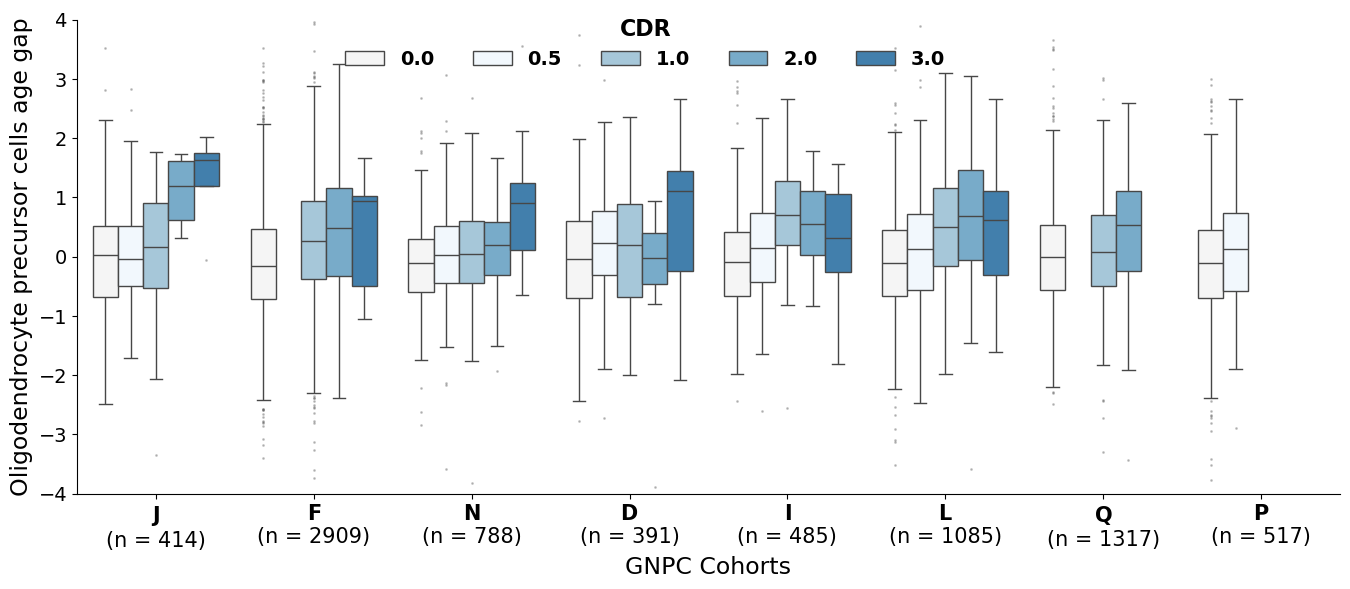

In [ ]:
# Define the cohorts we want to plot
cdr_cohort = ['J', 'F', 'N', 'D', 'I', 'L', 'Q', 'P']

# Filter the data to include only rows with CDR values, excluding -1
cdr_df = pl_meta_sex_idx[(pl_meta_sex_idx['cdr'].notna()) & 
                         (pl_meta_sex_idx['cdr'] != -1) &
                         (pl_meta_sex_idx['contributor_code'].isin(cdr_cohort))].copy()

# Merge with df_age_gap to get the cell type values
cdr_df_reset = cdr_df.reset_index(drop=True)
df_age_gap_reset = df_age_gap.reset_index(drop=True)
merged_df = cdr_df_reset.merge(df_age_gap_reset, on='sample_id', how='inner')

# Convert cdr to string type if it's not already
merged_df['cdr'] = merged_df['cdr'].astype(str)

# Calculate the number of samples for each cohort
cohort_counts = merged_df.groupby('contributor_code')['sample_id'].nunique()

# Create x-axis labels with BOLD cohort name and regular sample size
x_labels = []
for cohort in cdr_cohort:
    if cohort in cohort_counts.index:
        count = cohort_counts[cohort]
        x_labels.append(f'$\\mathbf{{{cohort}}}$\n(n = {count})')
    else:
        x_labels.append(f'$\\mathbf{{{cohort}}}$\n(n = 0)')

plt.figure(figsize=(16, 6))

hue_order = ["0.0", "0.5", "1.0", "2.0", "3.0"]
my_palette = ["whitesmoke", "aliceblue", "#9ecae1", "#6baed6", "#3182bd"]

ax = plt.gca()

# Plot boxplots for each selected cohort, grouped by CDR value
sns.boxplot(
    x='contributor_code',
    y='Oligodendrocyte precursor cells',  
    hue='cdr',
    data=merged_df,
    palette=my_palette,
    hue_order=hue_order,
    order=cdr_cohort,  
    width=0.8,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'gray',
        'markersize': 1,
        'alpha': 0.3
    },
    ax=ax
)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

legend = plt.legend(title="CDR", bbox_to_anchor=(0.45, 0.95), loc='center', ncol=5, fontsize=14)
legend.get_title().set_fontsize(16)
legend.get_title().set_fontweight('bold')  
legend.get_frame().set_edgecolor('none')  
legend.get_frame().set_facecolor('none')  

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xlabel('GNPC Cohorts', fontsize=17)
plt.ylabel('Oligodendrocyte precursor cells age gap', fontsize=17)  # Change this to match your cell type
plt.ylim(-4, 4)

ax.set_xticklabels(x_labels, fontsize=15)

plt.xticks(rotation=0, ha='center')
plt.yticks(fontsize=14)

plt.tight_layout(rect=[0, 0, 0.85, 1])  

filename = './Rev_results/figure3_cognition_opc_revision'
plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{filename}.svg", dpi=300, bbox_inches='tight', format='svg')
plt.savefig(f"{filename}.pdf", dpi=300, bbox_inches='tight', format='pdf')

plt.show()

/tmp/ipykernel_228/106552827.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels, fontsize=15)


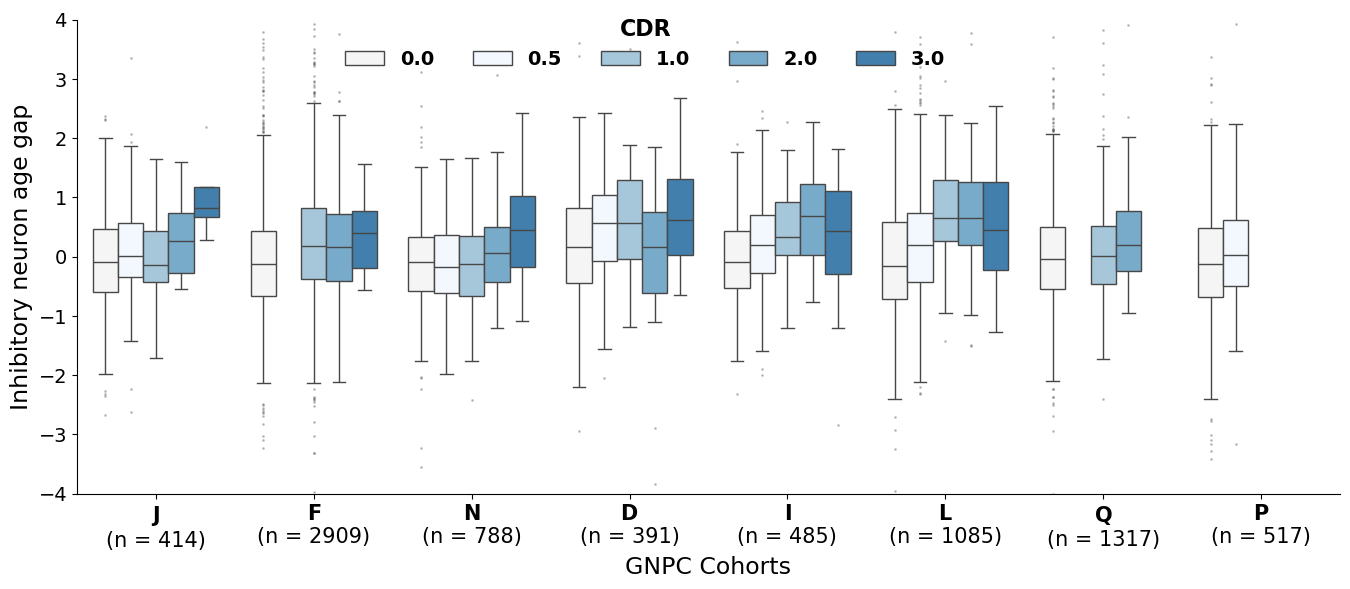

In [ ]:
# Define the cohorts we want to plot
cdr_cohort = ['J', 'F', 'N', 'D', 'I', 'L', 'Q', 'P']

# Filter the data to include only rows with CDR values, excluding -1
cdr_df = pl_meta_sex_idx[(pl_meta_sex_idx['cdr'].notna()) & 
                         (pl_meta_sex_idx['cdr'] != -1) &
                         (pl_meta_sex_idx['contributor_code'].isin(cdr_cohort))].copy()

# Merge with df_age_gap to get the cell type values
cdr_df_reset = cdr_df.reset_index(drop=True)
df_age_gap_reset = df_age_gap.reset_index(drop=True)
merged_df = cdr_df_reset.merge(df_age_gap_reset, on='sample_id', how='inner')

# Convert cdr to string type if it's not already
merged_df['cdr'] = merged_df['cdr'].astype(str)

# Calculate the number of samples for each cohort
cohort_counts = merged_df.groupby('contributor_code')['sample_id'].nunique()

# Create x-axis labels with BOLD cohort name and regular sample size
x_labels = []
for cohort in cdr_cohort:
    if cohort in cohort_counts.index:
        count = cohort_counts[cohort]
        x_labels.append(f'$\\mathbf{{{cohort}}}$\n(n = {count})')
    else:
        x_labels.append(f'$\\mathbf{{{cohort}}}$\n(n = 0)')

plt.figure(figsize=(16, 6))

hue_order = ["0.0", "0.5", "1.0", "2.0", "3.0"]
my_palette = ["whitesmoke", "aliceblue", "#9ecae1", "#6baed6", "#3182bd"]

ax = plt.gca()

# Plot boxplots for each selected cohort, grouped by CDR value
sns.boxplot(
    x='contributor_code',
    y='Inhibitory neurons', 
    hue='cdr',
    data=merged_df,
    palette=my_palette,
    hue_order=hue_order,
    order=cdr_cohort,  
    width=0.8,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'gray',
        'markersize': 1,
        'alpha': 0.3
    },
    ax=ax
)

# Remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

legend = plt.legend(title="CDR", bbox_to_anchor=(0.45, 0.95), loc='center', ncol=5, fontsize=14)
legend.get_title().set_fontsize(16)
legend.get_title().set_fontweight('bold') 
legend.get_frame().set_edgecolor('none') 
legend.get_frame().set_facecolor('none') 

for text in legend.get_texts():
    text.set_fontweight('bold')

plt.xlabel('GNPC Cohorts', fontsize=17)
plt.ylabel('Inhibitory neuron age gap', fontsize=17)  # Change this to match your cell type
plt.ylim(-4, 4)

# Set custom x-axis labels with sample sizes
ax.set_xticklabels(x_labels, fontsize=15)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha='center')
plt.yticks(fontsize=14)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust the rect to leave space for legend

filename = './Rev_results/figure3_cognition_inhib_revision'
plt.savefig(f"{filename}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{filename}.svg", dpi=300, bbox_inches='tight', format='svg')
plt.savefig(f"{filename}.pdf", dpi=300, bbox_inches='tight', format='pdf')

plt.show()